# Challenge Telecom X

## Objetivo do projeto
Este notebook foi estruturado para atender ao desafio de ETL e análise exploratória de churn da Telecom X.



## 1. Importação das bibliotecas

Neste projeto vamos utilizar:
- **requests** para extração dos dados
- **json** para leitura da resposta
- **pandas** para transformação
- **numpy** para apoio em tratamentos
- **matplotlib** e **seaborn** para visualização


In [1]:
import json
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")


## 2. Extração dos dados



In [2]:
URL_DADOS = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

response = requests.get(URL_DADOS, timeout=30)
response.raise_for_status()

dados_brutos = response.json()
type(dados_brutos), len(dados_brutos)


(list, 7267)

In [3]:
df_raw = pd.json_normalize(dados_brutos, sep="_")
df_raw.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4


## 3. Diagnóstico inicial da base



In [4]:
df_raw.shape


(7267, 21)

In [5]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [6]:
df_raw.describe(include="all").T.head(10)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7267,7267,9995-HOTOH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,7267,3,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_gender,7267,2,Male,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_SeniorCitizen,"7,267.00",NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
customer_Partner,7267,2,No,3749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_Dependents,7267,2,No,5086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_tenure,"7,267.00",NaN,NaN,NaN,32.35,24.57,0.00,9.00,29.00,55.00,72.00
phone_PhoneService,7267,2,Yes,6560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone_MultipleLines,7267,3,No,3495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_InternetService,7267,3,Fiber optic,3198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Função auxiliar para detectar ausentes lógicos



In [7]:
def mask_ausente_logico(df: pd.DataFrame, col: str, tokens=None) -> pd.Series:
    """Retorna uma máscara booleana para ausentes técnicos ou lógicos."""
    if tokens is None:
        tokens = ["null", "none", "na", "n/a", "nan"]

    cond_nan = df[col].isna()
    col_norm = df[col].astype(str).str.strip().str.lower()
    cond_vazio = col_norm == ""
    cond_tokens = col_norm.isin(tokens)

    return cond_nan | cond_vazio | cond_tokens


In [8]:
resumo_ausentes = pd.DataFrame({
    "ausentes_logicos": {
        "Churn": mask_ausente_logico(df_raw, "Churn").sum(),
        "account_Charges_Total": mask_ausente_logico(df_raw, "account_Charges_Total").sum()
    }
})

resumo_ausentes


,ausentes_logicos
Churn,224
account_Charges_Total,11


### Principais achados do diagnóstico
- A coluna **`Churn`** possui registros vazios.
- A coluna **`account_Charges_Total`** também possui valores vazios.
- Como `account_Charges_Total` deveria ser numérica, isso impede a conversão direta com `astype(float)`.


## 5. Investigação de inconsistências




In [9]:
mask_total_vazio = mask_ausente_logico(df_raw, "account_Charges_Total")

df_raw.loc[
    mask_total_vazio,
    ["customerID", "customer_tenure", "account_Charges_Monthly", "account_Charges_Total", "Churn"]
]


,customerID,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn
975,1371-DWPAZ,0,56.05,,No
1775,2520-SGTTA,0,20.00,,No
1955,2775-SEFEE,0,61.90,,No
2075,2923-ARZLG,0,19.70,,No
2232,3115-CZMZD,0,20.25,,No
2308,3213-VVOLG,0,25.35,,No
2930,4075-WKNIU,0,73.35,,No
3134,4367-NUYAO,0,25.75,,No
3203,4472-LVYGI,0,52.55,,No
4169,5709-LVOEQ,0,80.85,,No


### Interpretação

> clientes recém-entrados ainda não acumularam cobrança total, então o total acumulado deve ser **0**.


In [10]:
(df_raw["customer_tenure"] == 0).sum(), mask_total_vazio.sum()


(np.int64(11), np.int64(11))

A validação acima mostra que:
- existem **11 clientes com tenure = 0**
- e exatamente os mesmos **11 clientes** têm `account_Charges_Total` vazio

Portanto, o tratamento para `account_Charges_Total` é seguro.


## 6. Transformação e limpeza dos dados


In [11]:
df = df_raw.copy()

df["account_Charges_Total"] = pd.to_numeric(
    df["account_Charges_Total"],
    errors="coerce"
).fillna(0)

df["Churn"] = df["Churn"].replace(r"^\s*$", np.nan, regex=True)

df["Churn"].value_counts(dropna=False)


,count
Churn,
No,5174
Yes,1869
NaN,224


In [12]:
df["account_Charges_Total"].dtype, df["account_Charges_Total"].isna().sum()


(dtype('float64'), np.int64(0))

In [13]:
df_analise = df[df["Churn"].notna()].copy()
df_analise["Churn_bin"] = df_analise["Churn"].map({"No": 0, "Yes": 1})

df.shape, df_analise.shape


((7267, 21), (7043, 22))

## 7. Verificação de consistência entre colunas categóricas



In [14]:
consistencia_phone = pd.crosstab(
    df["phone_PhoneService"],
    df["phone_MultipleLines"],
    margins=True
)

consistencia_phone


phone_MultipleLines,No,No phone service,Yes,All
phone_PhoneService,,,,
No,0,707,0,707
Yes,3495,0,3065,6560
All,3495,707,3065,7267


In [15]:
colunas_internet = [
    "internet_OnlineSecurity",
    "internet_OnlineBackup",
    "internet_DeviceProtection",
    "internet_TechSupport",
    "internet_StreamingTV",
    "internet_StreamingMovies"
]

{
    col: df[col].value_counts().to_dict()
    for col in colunas_internet
}


{'internet_OnlineSecurity': {'No': 3608,
  'Yes': 2078,
  'No internet service': 1581},
 'internet_OnlineBackup': {'No': 3182,
  'Yes': 2504,
  'No internet service': 1581},
 'internet_DeviceProtection': {'No': 3195,
  'Yes': 2491,
  'No internet service': 1581},
 'internet_TechSupport': {'No': 3582,
  'Yes': 2104,
  'No internet service': 1581},
 'internet_StreamingTV': {'No': 2896,
  'Yes': 2790,
  'No internet service': 1581},
 'internet_StreamingMovies': {'No': 2870,
  'Yes': 2816,
  'No internet service': 1581}}

## 8. Análise exploratória — visão geral do churn


In [16]:
churn_geral = (
    df_analise["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentual")
)

churn_geral


,percentual
Churn,
No,73.46
Yes,26.54


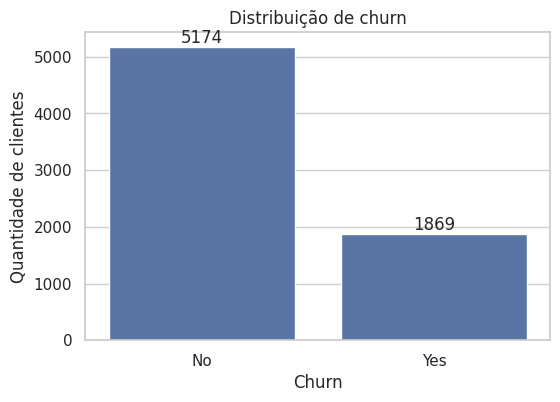

In [17]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_analise, x="Churn")
ax.bar_label(ax.containers[0], fmt="%d")
plt.title("Distribuição de churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de clientes")
plt.show()


## 9. Churn por tipo de contrato


In [18]:
churn_contrato = (
    df_analise.groupby("account_Contract")["Churn_bin"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

churn_contrato["mean_pct"] = (churn_contrato["mean"] * 100).round(2)
churn_contrato


,mean,count,mean_pct
account_Contract,,,
Month-to-month,0.43,3875,42.71
One year,0.11,1473,11.27
Two year,0.03,1695,2.83


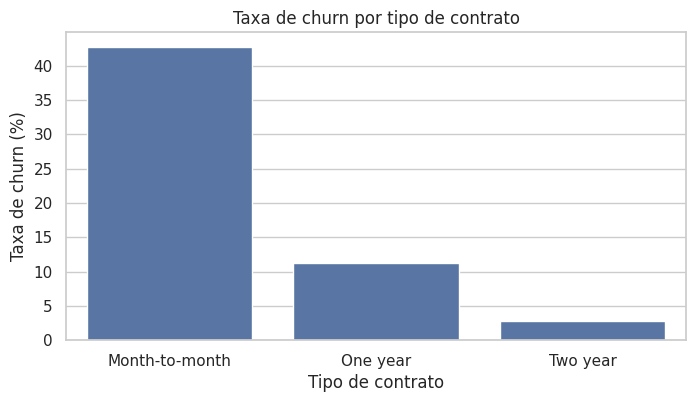

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=churn_contrato.reset_index(),
    x="account_Contract",
    y="mean_pct"
)
plt.title("Taxa de churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Taxa de churn (%)")
plt.show()


## 10. Churn por tipo de serviço de internet


In [20]:
churn_internet = (
    df_analise.groupby("internet_InternetService")["Churn_bin"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

churn_internet["mean_pct"] = (churn_internet["mean"] * 100).round(2)
churn_internet


,mean,count,mean_pct
internet_InternetService,,,
Fiber optic,0.42,3096,41.89
DSL,0.19,2421,18.96
No,0.07,1526,7.40


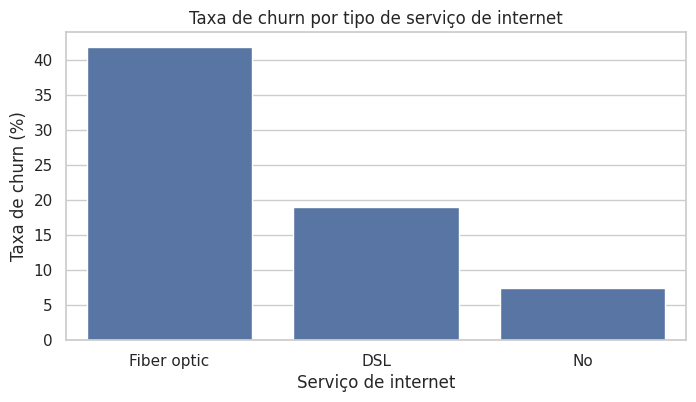

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=churn_internet.reset_index(),
    x="internet_InternetService",
    y="mean_pct"
)
plt.title("Taxa de churn por tipo de serviço de internet")
plt.xlabel("Serviço de internet")
plt.ylabel("Taxa de churn (%)")
plt.show()


## 11. Churn por método de pagamento


In [22]:
churn_pagamento = (
    df_analise.groupby("account_PaymentMethod")["Churn_bin"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

churn_pagamento["mean_pct"] = (churn_pagamento["mean"] * 100).round(2)
churn_pagamento


,mean,count,mean_pct
account_PaymentMethod,,,
Electronic check,0.45,2365,45.29
Mailed check,0.19,1612,19.11
Bank transfer (automatic),0.17,1544,16.71
Credit card (automatic),0.15,1522,15.24


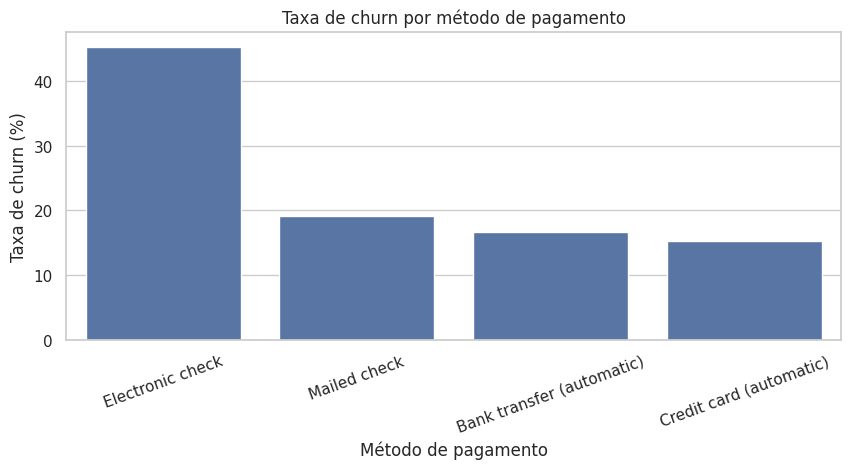

In [23]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=churn_pagamento.reset_index(),
    x="account_PaymentMethod",
    y="mean_pct"
)
plt.title("Taxa de churn por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Taxa de churn (%)")
plt.xticks(rotation=20)
plt.show()


## 12. Churn por faixa etária (Senior Citizen)


In [24]:
churn_senior = (
    df_analise.groupby("customer_SeniorCitizen")["Churn_bin"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

churn_senior["mean_pct"] = (churn_senior["mean"] * 100).round(2)
churn_senior


,mean,count,mean_pct
customer_SeniorCitizen,,,
1,0.42,1142,41.68
0,0.24,5901,23.61


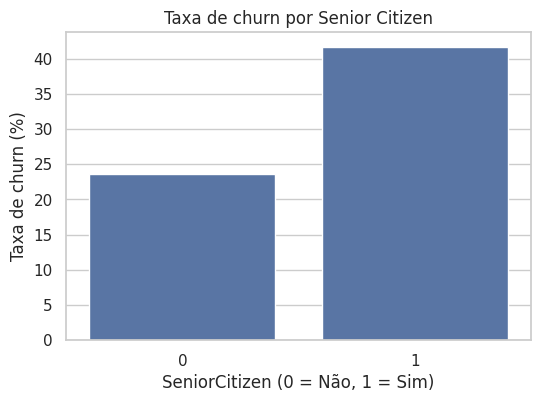

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=churn_senior.reset_index(),
    x="customer_SeniorCitizen",
    y="mean_pct"
)
plt.title("Taxa de churn por Senior Citizen")
plt.xlabel("SeniorCitizen (0 = Não, 1 = Sim)")
plt.ylabel("Taxa de churn (%)")
plt.show()


## 13. Tempo de casa e cobranças

Além das categorias, também vale comparar variáveis numéricas.


In [26]:
comparativo_numerico = (
    df_analise.groupby("Churn")[["customer_tenure", "account_Charges_Monthly", "account_Charges_Total"]]
    .agg(["mean", "median"])
    .round(2)
)

comparativo_numerico


customer_tenure        account_Charges_Monthly         \
                 mean median                    mean median   
Churn                                                         
No              37.57  38.00                   61.27  64.43   
Yes             17.98  10.00                   74.44  79.65   

      account_Charges_Total           
                       mean   median  
Churn                                 
No                 2,549.91 1,679.52  
Yes                1,531.80   703.55

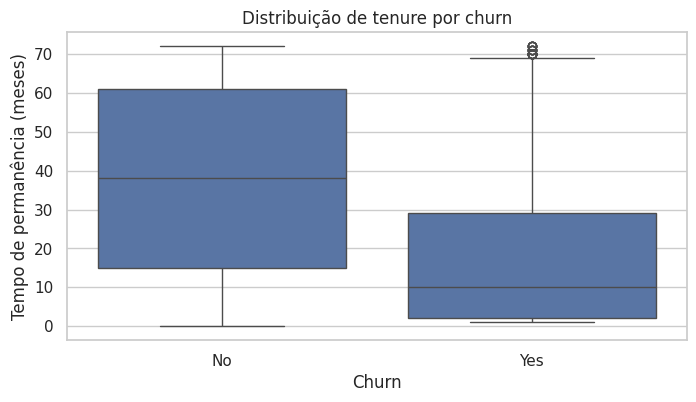

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_analise, x="Churn", y="customer_tenure")
plt.title("Distribuição de tenure por churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de permanência (meses)")
plt.show()


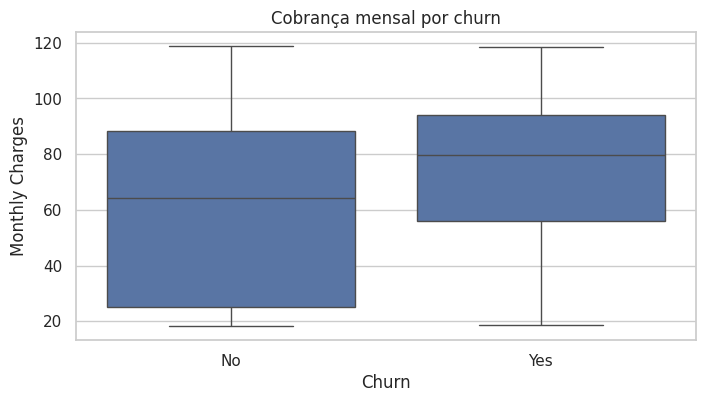

In [28]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_analise, x="Churn", y="account_Charges_Monthly")
plt.title("Cobrança mensal por churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


## 14. Investigação dos registros com Churn vazio



In [29]:
mask_churn_vazio = df["Churn"].isna()

comparativo_churn_vazio = pd.DataFrame({
    "Contrato - vazio": df.loc[mask_churn_vazio, "account_Contract"].value_counts(normalize=True).round(4),
    "Contrato - preenchido": df.loc[~mask_churn_vazio, "account_Contract"].value_counts(normalize=True).round(4)
}).fillna(0)

comparativo_churn_vazio


,Contrato - vazio,Contrato - preenchido
account_Contract,,
Month-to-month,0.58,0.55
Two year,0.21,0.24
One year,0.21,0.21


In [30]:
comparativo_senior_vazio = pd.DataFrame({
    "SeniorCitizen - vazio": df.loc[mask_churn_vazio, "customer_SeniorCitizen"].value_counts(normalize=True).round(4),
    "SeniorCitizen - preenchido": df.loc[~mask_churn_vazio, "customer_SeniorCitizen"].value_counts(normalize=True).round(4)
}).fillna(0)

comparativo_senior_vazio


,SeniorCitizen - vazio,SeniorCitizen - preenchido
customer_SeniorCitizen,,
0,0.82,0.84
1,0.18,0.16


In [31]:
df.loc[mask_churn_vazio, "customer_tenure"].describe().round(2)


,customer_tenure
count,224.00
mean,31.57
std,25.00
min,1.00
25%,7.00
50%,29.00
75%,56.00
max,72.00


### Observações
Em minha analise identifiquei que os 224 registros sem rótulo de churn:
- representam pouco mais de **3%** da base
- não estão ligados aos 11 casos de `tenure = 0`
- parecem distribuídos de forma relativamente parecida com a base preenchida em algumas variáveis

